Load & preprocess

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

iris = load_iris()
X = iris.data
y = iris.target

# Standardize manually
X_meaned = X - np.mean(X, axis=0)


Covariance matrix

In [2]:
cov_mat = np.cov(X_meaned, rowvar=False)


Eigenvalues & eigenvectors

In [3]:
eigen_vals, eigen_vecs = np.linalg.eigh(cov_mat)


Sort descending

In [4]:
sorted_idx = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[sorted_idx]
eigen_vecs = eigen_vecs[:, sorted_idx]


Select 2 components

In [5]:
eigenvector_subset = eigen_vecs[:, :2]


Transform data

In [6]:
X_reduced = np.dot(eigenvector_subset.T, X_meaned.T).T


Plot

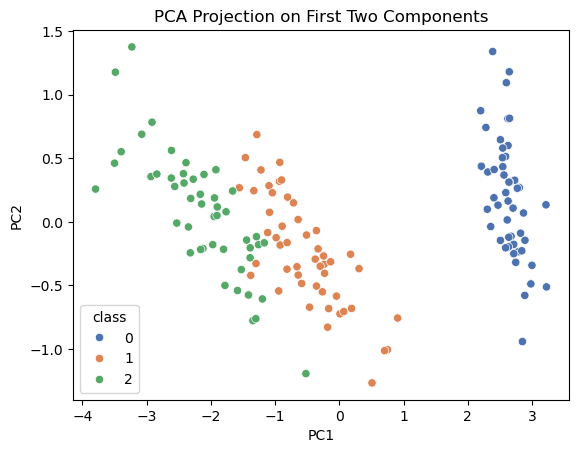

In [7]:
df = pd.DataFrame(X_reduced, columns=['PC1','PC2'])
df['class'] = y

sns.scatterplot(data=df, x='PC1', y='PC2', hue='class', palette='deep')
plt.title("PCA Projection on First Two Components")
plt.show()


# PCA vs t-SNE vs UMAP on Iris


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Hp\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


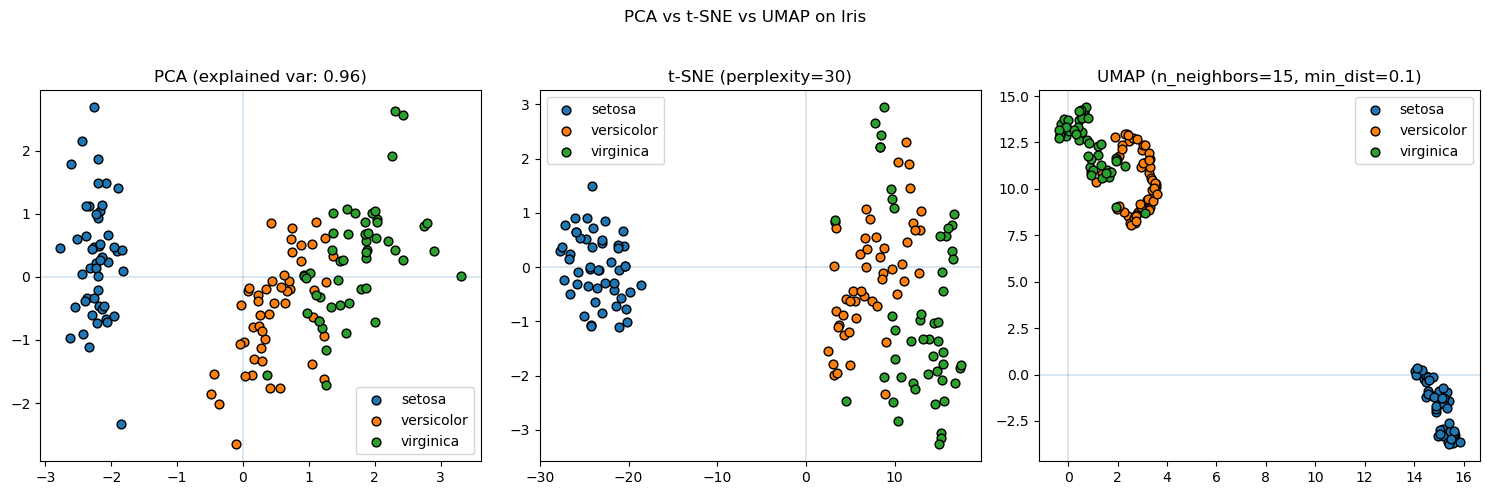


PCA explained variance ratios: [0.72962445 0.22850762]


In [11]:
# PCA vs t-SNE vs UMAP on Iris
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Optional: install umap-learn if not present:
# pip install umap-learn
try:
    import umap
except Exception as e:
    umap = None
    print("umap not available. Install with: pip install umap-learn")

# Load data
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Standardize (very important for PCA and t-SNE/UMAP preprocessing)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 1) PCA (linear)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

# 2) t-SNE (nonlinear)
# Note: t-SNE is stochastic — results vary across runs unless random_state fixed.
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_std)

# 3) UMAP (nonlinear) — if available
X_umap = None
if umap is not None:
    umapper = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = umapper.fit_transform(X_std)

# Plotting
fig, axes = plt.subplots(1, 3 if X_umap is not None else 2, figsize=(15, 5))

# Helper to plot
def scatter(ax, proj, title):
    for label in np.unique(y):
        ax.scatter(proj[y == label, 0], proj[y == label, 1], label=target_names[label], s=40, edgecolor='k')
    ax.set_title(title)
    ax.legend()
    ax.axhline(0, linewidth=0.25)
    ax.axvline(0, linewidth=0.25)

scatter(axes[0], X_pca, f"PCA (explained var: {pca.explained_variance_ratio_.sum():.2f})")
scatter(axes[1], X_tsne, "t-SNE (perplexity=30)")
if X_umap is not None:
    scatter(axes[2], X_umap, "UMAP (n_neighbors=15, min_dist=0.1)")

plt.suptitle("PCA vs t-SNE vs UMAP on Iris")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print quick numeric summaries for viva
print("\nPCA explained variance ratios:", pca.explained_variance_ratio_)


In [9]:
pip install umap-learn


   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]

Note: you may need to restart the kernel to use updated packages.
